In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

train_df = pd.read_csv("data\\train.csv")
val_df = pd.read_csv("data\\validation.csv")

In [3]:
vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])
X_train = vectorizer.transform(train_df['full_name'])
X_val = vectorizer.transform(val_df['full_name'])

y_train = train_df['label']
y_val = val_df['label']

In [4]:
svc = SVC(random_state = 42, C = 1, gamma = 1)
svc.fit(X_train, y_train)
predicted_y = svc.predict(X_val)

In [5]:
accuracy = accuracy_score(y_val, predicted_y) * 100

recall = recall_score(y_val, predicted_y) * 100

precision = precision_score(y_val, predicted_y) * 100

f1= f1_score(y_val, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_val, predicted_y))

Accuracy: 90.24533472530341
Recall: 95.99686028257457
Precision: 86.05605722997537
f1_score: 90.75505534598973

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7682
           1       0.86      0.96      0.91      7644

    accuracy                           0.90     15326
   macro avg       0.91      0.90      0.90     15326
weighted avg       0.91      0.90      0.90     15326



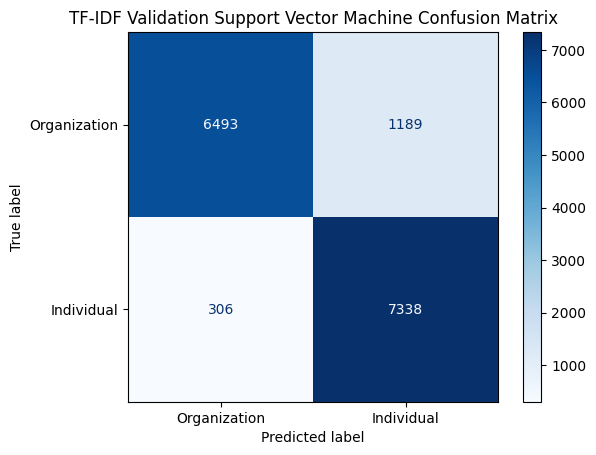

In [6]:
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title('TF-IDF Validation Support Vector Machine Confusion Matrix')
plt.savefig('TF-IDF Validation Support Vector Machine Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [13]:
#test_df = pd.read_csv("data\\test.csv")
test_df = pd.read_csv("data\mi_mn_annotated.csv")
#X_test = vectorizer.transform(test_df['full_name'])
X_test = vectorizer.transform(test_df['merged_full_name']) # 'full_name'
#y_test = test_df['label']

In [14]:
def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'Individual':
        return 1
    else:
        return 0
y_test = np.vectorize(convert_bool)(test_df['transactor_type'])

In [15]:
predicted_y_test = svc.predict(X_test)
print(classification_report(y_test, predicted_y_test))

              precision    recall  f1-score   support

           0       0.55      0.99      0.71      4924
           1       1.00      0.94      0.97     71780

    accuracy                           0.95     76704
   macro avg       0.77      0.97      0.84     76704
weighted avg       0.97      0.95      0.95     76704



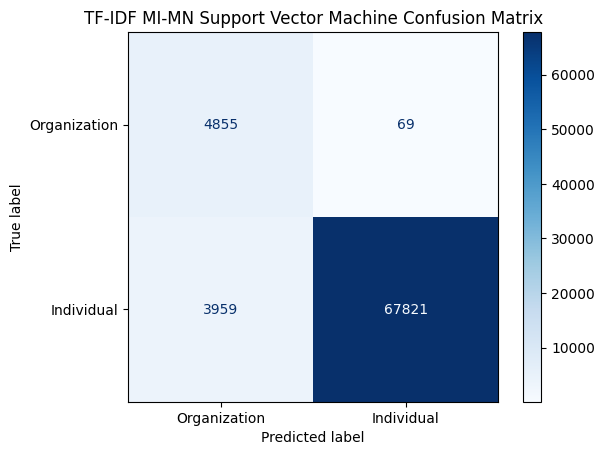

In [18]:
cm = confusion_matrix(y_test, predicted_y_test, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title('TF-IDF MI-MN Support Vector Machine Confusion Matrix')
plt.savefig('TF-IDF MI-MN Support Vector Machine Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [11]:
misclassified = np.where(y_test != predicted_y_test)[0]
y_test_df = y_test.reset_index().copy()

inverse_names = vectorizer.inverse_transform(X_test)

inverse_names_clean = []
for i in misclassified:
	inverse_names_clean.append(" ".join(list(inverse_names[i])))

print(f"Number of misclassified samples: {len(misclassified)}")
ctr = -1
for i in misclassified:
	ctr+=1
	print(f"ctr: {ctr}")
	print(f"Index: {i}")
	print(f"Full Name: {inverse_names_clean[ctr]}")
	print(f"True Label: {y_test_df.iloc[i]['label']}, Predicted: {predicted_y[i]}")
	print("---")
# Organization = 0
# Individual = 1

Number of misclassified samples: 2883
ctr: 0
Index: 17
Full Name: bowen tom
True Label: 0, Predicted: 0
---
ctr: 1
Index: 18
Full Name: ann kirkpatrick
True Label: 0, Predicted: 1
---
ctr: 2
Index: 23
Full Name: georgia jackson
True Label: 0, Predicted: 1
---
ctr: 3
Index: 30
Full Name: james waring
True Label: 1, Predicted: 1
---
ctr: 4
Index: 34
Full Name: collett ryan
True Label: 0, Predicted: 1
---
ctr: 5
Index: 52
Full Name: mccreary tee
True Label: 0, Predicted: 1
---
ctr: 6
Index: 53
Full Name: becky jackson
True Label: 0, Predicted: 1
---
ctr: 7
Index: 83
Full Name: mendoza raul
True Label: 0, Predicted: 0
---
ctr: 8
Index: 86
Full Name: joe pyritz
True Label: 0, Predicted: 1
---
ctr: 9
Index: 115
Full Name: andrei cherny
True Label: 0, Predicted: 0
---
ctr: 10
Index: 119
Full Name: lynn stanley
True Label: 0, Predicted: 1
---
ctr: 11
Index: 133
Full Name: mitchell pat
True Label: 0, Predicted: 1
---
ctr: 12
Index: 141
Full Name: martinez silvia
True Label: 0, Predicted: 1
---


IndexError: index 15344 is out of bounds for axis 0 with size 15326

In [ ]:
inverse_names[24400]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (1, 48565)>
  Coords	Values
  (0, 21405)	1.0


In [ ]:
# from sklearn.model_selection import GridSearchCV 

# param_grid = {'C': [0.1, 1, 10, 100, 1000], 
# 			'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
# 			'kernel': ['rbf']} 

# grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3) 
 
# grid.fit(X_train, y_train)

In [ ]:
# print(grid.best_params_) 
 
# print(grid.best_estimator_)

In [ ]:
# grid_predictions = grid.predict(y_val) 

# print(classification_report(y_val, grid_predictions))